In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

Step - 1 Preprocess Audio Files
A single function that:

Loads any audio file
Converts it to mono
Resamples it to 16 kHz
Normalizes loudness
Returns a clean NumPy array

This function will be used everywhere: indexing songs, querying clips, testing.

In [2]:
def load_and_preprocess_audio(
    file_path: str,
    target_sr: int = 16000,
    normalize: bool = True
) -> tuple[np.ndarray, int]:
    """
    Load an audio file and convert it into a standardized mono signal.

    Returns:
        audio (np.ndarray): 1D mono signal
        sr (int): sample rate (always target_sr)
    """
    # Load audio
    audio, sr = librosa.load(
        file_path,
        sr=target_sr,
        mono=True
    )

    # Ensure type consistency
    audio = audio.astype(np.float32)

    # Normalize amplitude
    if normalize:
        peak = np.max(np.abs(audio))
        if peak > 0:
            audio = audio / peak

    return audio, target_sr


In [3]:
file = "one_dance_10s.mp3"

In [4]:
audio, sr = load_and_preprocess_audio(file)

print("Sample rate:", sr)
print("Shape:", audio.shape)
print("Min / Max:", audio.min(), audio.max())


Sample rate: 16000
Shape: (212736,)
Min / Max: -0.9929112 1.0


In [5]:
a1, _ = load_and_preprocess_audio(file)
a2, _ = load_and_preprocess_audio(file)

np.allclose(a1, a2, atol=1e-5)


True

Step 2: Spectrogram generation

Right now you have clean, standardized audio:
a 1D time-domain signal.

But fingerprints don’t work in time domain.

In this step, we’ll:

Convert audio from time → frequency over time

Produce a spectrogram

Lock down parameters so spectrograms are comparable across files

This is the bridge between raw sound and fingerprints.

What this step will output

From Step 2, you’ll get:

A 2D matrix: (frequency_bins, time_frames)

Values representing energy in dB

This matrix is the input for peak detection in the next step.

We’ll use:

STFT (Short-Time Fourier Transform)

Window size: 2048

Hop length: 512

Magnitude → decibels

These values are a sweet spot:

Good time resolution

Good frequency resolution

Common in audio fingerprinting systems

In [6]:
def compute_spectrogram(
    audio: np.ndarray,
    sr: int,
    n_fft: int = 2048,
    hop_length: int = 512
) -> np.ndarray:
    """
    Convert time-domain audio into a log-magnitude spectrogram.

    Returns:
        S_db (np.ndarray): shape (freq_bins, time_frames)
    """
    # Short-Time Fourier Transform
    S = librosa.stft(
        audio,
        n_fft=n_fft,
        hop_length=hop_length,
        window="hann"
    )

    # Magnitude
    S_mag = np.abs(S)

    # Convert to decibels
    S_db = librosa.amplitude_to_db(S_mag, ref=np.max)

    return S_db


Why each part exists (important)

librosa.stft: 
Splits audio into short overlapping windows
FFT on each window
Preserves time alignment

hann window:
Reduces spectral leakage
Standard choice for music analysis

Magnitude only:
Phase is unstable and noisy
Fingerprinting relies on energy peaks, not phase

dB scale:
Compresses dynamic range
Makes thresholding meaningful
Matches human perception

In [7]:
audio, sr = load_and_preprocess_audio(file)
S_db = compute_spectrogram(audio, sr)

print("Spectrogram shape:", S_db.shape)
print("Min / Max dB:", S_db.min(), S_db.max())


Spectrogram shape: (1025, 416)
Min / Max dB: -80.0 0.0


In [8]:
S_db[0]

array([-60.27097 , -39.453438, -39.25731 , -53.67604 , -57.30782 ,
       -55.453384, -42.772377, -43.723278, -37.910496, -40.02292 ,
       -56.92031 , -52.409046, -35.36477 , -33.796844, -45.843185,
       -54.66832 , -49.009575, -48.94615 , -52.665283, -47.93627 ,
       -44.688408, -50.2339  , -49.22403 , -52.502266, -41.66073 ,
       -52.30802 , -45.44419 , -36.719223, -51.589256, -51.53435 ,
       -63.402508, -43.424053, -49.171135, -64.19335 , -80.      ,
       -45.125458, -45.030575, -69.80263 , -59.2226  , -57.14452 ,
       -72.83073 , -57.85339 , -52.97858 , -38.796936, -43.88622 ,
       -38.94799 , -40.849686, -38.152756, -44.315437, -48.27169 ,
       -80.      , -56.03364 , -44.26056 , -46.161545, -73.354675,
       -43.569412, -51.297234, -67.94339 , -49.81346 , -50.524292,
       -37.90632 , -42.153244, -51.56053 , -51.161774, -59.575817,
       -44.231083, -42.08957 , -72.716255, -64.98923 , -53.898743,
       -48.585403, -42.836113, -44.39377 , -51.144993, -63.367

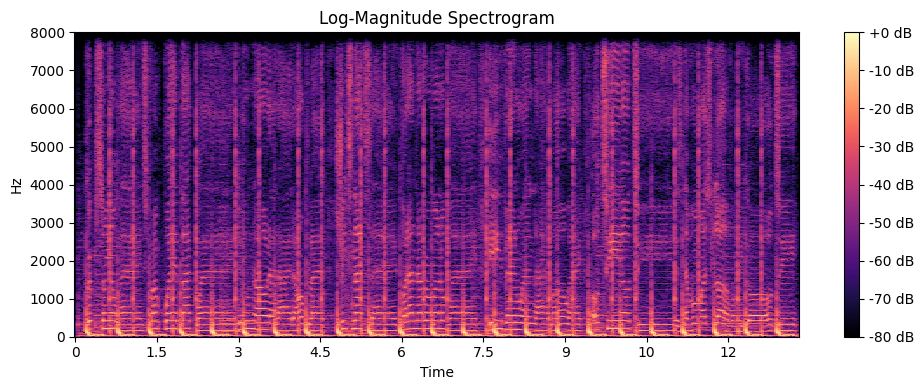

In [9]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Log-Magnitude Spectrogram")
plt.tight_layout()
plt.show()

Step 3: Peak detection

What we’re doing in this step (brief, first)

From the spectrogram you just saw, we will:
Identify only the strongest, most stable points
Throw away 95%+ of the data

Keep points that are:
Loud relative to neighbors
Isolated in time–frequency space
Likely to survive noise and compression
These points are called spectral peaks.
They are the raw material for fingerprints.

Why we even need peak detection

Your spectrogram is dense:

Thousands of frequencies
Hundreds of time frames
Mostly redundant or noisy energy


Fingerprinting works because:

The same song produces the same strong peaks, even under noise.
Weak energy is unreliable. Peaks are not.

So the rule is simple:
If it’s not a local maximum, we don’t care.

What a “peak” means here (precise definition)

A point (f, t) is a peak if:

Its magnitude is higher than its neighbors

It’s above a minimum dB threshold

Neighbors mean:

Nearby frequencies

Nearby time frames

This gives us local maxima in 2D.

Implementation strategy (important)

We will:

Use a 2D max filter to find local maxima

Apply a dB threshold

Extract (time_index, freq_index) pairs

In [10]:
def find_spectral_peaks(
    S_db: np.ndarray,
    amp_min: float = -40,
    neighborhood_size: int = 20
) -> list[tuple[int, int]]:
    """
    Find local spectral peaks in a log-magnitude spectrogram.

    Returns:
        peaks: list of (time_index, freq_index)
    """
    # Apply local maximum filter
    local_max = maximum_filter(
        S_db,
        size=(neighborhood_size, neighborhood_size)
    ) == S_db

    # Apply amplitude threshold
    detected_peaks = local_max & (S_db >= amp_min)

    # Get indices
    freq_idxs, time_idxs = np.where(detected_peaks)

    # Convert to (time, freq) tuples
    peaks = list(zip(time_idxs, freq_idxs))

    return peaks


In [11]:
peaks = find_spectral_peaks(S_db)

print("Number of peaks:", len(peaks))
peaks[:10]  # Show first 10 peaks

Number of peaks: 677


[(np.int64(10), np.int64(5)),
 (np.int64(28), np.int64(5)),
 (np.int64(46), np.int64(5)),
 (np.int64(64), np.int64(5)),
 (np.int64(82), np.int64(5)),
 (np.int64(100), np.int64(5)),
 (np.int64(118), np.int64(5)),
 (np.int64(136), np.int64(5)),
 (np.int64(154), np.int64(5)),
 (np.int64(172), np.int64(5))]

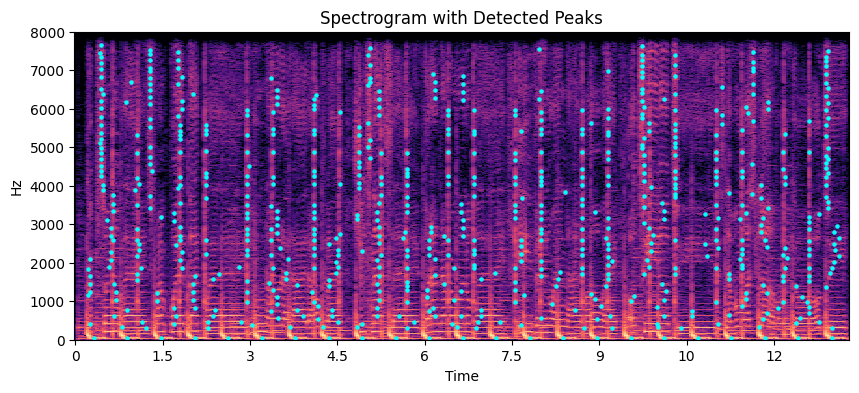

In [12]:
times = [t for t, f in peaks]
freqs = [f for t, f in peaks]

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="hz"
)
plt.scatter(
    np.array(times) * 512 / sr,
    np.array(freqs) * sr / 2048,
    s=5,
    c="cyan"
)
plt.title("Spectrogram with Detected Peaks")
plt.show()

Why this peak distribution is good for fingerprinting

Fingerprinting relies on combinatorics, not raw peak count.

Later, we’ll:

Pick an anchor peak

Pair it with nearby peaks in time

Generate hashes like (f1, f2, Δt)

With ~600–700 peaks:

You get thousands of candidate hashes

But only consistent ones survive matching

That’s exactly how robustness emerges.

Step 4: Fingerprint hashing (anchor–target pairs)

This is where your system stops being “signal processing” and becomes a search engine.

What we’re doing in this step (brief, first)

From the peaks you already extracted, we will:

Pick one peak as an anchor

Pair it with nearby future peaks (targets)

Encode each pair into a compact hash

Keep enough timing info to align matches later

After this step, your audio is no longer “audio”.
It’s a bag of hashes you can index and search.

Why we don’t hash single peaks

A single peak (f, t) is weak:

Noise can move it

Compression can remove it

Many songs share similar frequencies

A pair of peaks is much more distinctive:

Two frequencies

Their time distance

Relative structure survives noise

That’s the robustness trick.

We will use:

Fan-out: 5 (each anchor pairs with 5 targets)

Max time delta: ~2 seconds

Only forward pairing (t2 > t1)

These values are conservative and stable.

In [22]:
def generate_fingerprints(
    peaks: list[tuple[int, int]],
    fan_value: int = 5,
    min_time_delta: int = 1,
    max_time_delta: int = 200
) -> list[tuple[str, int]]:
    """
    Generate fingerprint hashes from spectral peaks.

    Args:
        peaks: list of (time_idx, freq_idx)
        fan_value: number of target peaks per anchor
        min_time_delta: minimum time difference (frames)
        max_time_delta: maximum time difference (frames)

    Returns:
        fingerprints: list of (hash, offset)
    """
    fingerprints = []

    # Sort peaks by time
    peaks = sorted(peaks, key=lambda x: x[0])

    for i in range(len(peaks)):
        t1, f1 = peaks[i]

        for j in range(1, fan_value + 1):
            if i + j >= len(peaks):
                break

            t2, f2 = peaks[i + j]
            delta_t = t2 - t1

            if min_time_delta <= delta_t <= max_time_delta:
                # Create hash (string for now, DB-friendly)
                hash_key = f"{f1}|{f2}|{delta_t}"

                fingerprints.append((hash_key, int(t1)))

    return fingerprints


In [14]:
fingerprints = generate_fingerprints(peaks)

print("Number of fingerprints:", len(fingerprints))
print("Sample fingerprints:", fingerprints[:5])

Number of fingerprints: 1654
Sample fingerprints: [('148|52|1', np.int64(7)), ('148|159|1', np.int64(7)), ('148|186|1', np.int64(7)), ('148|213|1', np.int64(7)), ('234|52|1', np.int64(7))]


Transformed:
Audio → Spectrogram → Peaks → Hashes

At this point:

You could delete the audio file

You could delete the spectrogram

Matching would still work

This is the whole point of fingerprinting.

The hash says “this sound exists”, the offset says “where it exists”, and matching happens when many hashes agree on the same where.

Step 5: Database schema & storage

Step 6 — Indexing pipeline
What we’re doing in this step (brief)

We will:

Connect Python to PostgreSQL

Insert a song’s metadata

Generate fingerprints for that song

Bulk insert fingerprints efficiently

By the end of this step:

A song is fully indexed with one command

Its fingerprints live in the database

The system is ready to answer queries later

In [17]:
import psycopg2
from psycopg2.extras import execute_values

def get_db_connection():
    return psycopg2.connect(
        dbname="audio_fingerprint",
        user="postgres",
        password="admin@123",
        host="localhost",
        port=5432
    )


In [40]:
conn = get_db_connection()
cur = conn.cursor()

In [43]:
def insert_song(title: str, artist: str, duration: float) -> int:

    cur.execute(
        """
        INSERT INTO songs (title, artist, duration)
        VALUES (%s, %s, %s)
        RETURNING id
        """,
        (title, artist, duration)
    )

    row = cur.fetchone()
    if row is None:
        raise RuntimeError("Insert failed, no ID returned")

    song_id = row[0]
    conn.commit()


    return song_id


In [44]:
def insert_fingerprints(
    fingerprints: list[tuple[str, int]],
    song_id: int
):

    values = [
        (hash_key, song_id, offset)
        for hash_key, offset in fingerprints
    ]

    execute_values(
        cur,
        """
        INSERT INTO fingerprints (hash, song_id, song_offset)
        VALUES %s
        """,
        values
    )

    conn.commit()
    


In [26]:
def index_song(
    file_path: str,
    title: str,
    artist: str
):
    # Step 1: preprocess
    audio, sr = load_and_preprocess_audio(file_path)
    duration = len(audio) / sr

    # Step 2: spectrogram
    S_db = compute_spectrogram(audio, sr)

    # Step 3: peak detection
    peaks = find_spectral_peaks(S_db)

    # Step 4: fingerprint hashing
    fingerprints = generate_fingerprints(peaks)

    # Step 5: database inserts
    song_id = insert_song(title, artist, duration)
    insert_fingerprints(fingerprints, song_id)

    print(
        f"Indexed '{title}' "
        f"({len(fingerprints)} fingerprints)"
    )


In [27]:
index_song(
    "one_dance.mp3",
    "One Dance",
    "Drake"
)

Indexed 'One Dance' (16557 fingerprints)


In [28]:
index_song(
    "im_the_one.mp3",
    "I'm The One",
    "DJ Khaled"
)

Indexed 'I'm The One' (40294 fingerprints)


In [59]:
def fetch_matches_for_hashes(cur, hash_keys: list[str]):

    cur.execute(
        """
        SELECT hash, song_id, song_offset
        FROM fingerprints
        WHERE hash = ANY(%s)
        """,
        (hash_keys,)
    )

    rows = cur.fetchall()

    return rows


In [63]:
from collections import defaultdict, Counter

def identify_song_fast(cur, file_path: str):
    
    audio, sr = load_and_preprocess_audio(file_path)
    S_db = compute_spectrogram(audio, sr)
    peaks = find_spectral_peaks(S_db)
    query_fingerprints = generate_fingerprints(peaks)

    # Map query offsets
    query_offsets = {}
    for hash_key, offset in query_fingerprints:
        query_offsets.setdefault(hash_key, []).append(offset)

    unique_hashes = list(query_offsets.keys())

    rows = fetch_matches_for_hashes(cur, unique_hashes)

    offset_votes = defaultdict(Counter)

    for hash_key, song_id, db_offset in rows:
        for q_offset in query_offsets[hash_key]:
            delta = db_offset - q_offset
            offset_votes[song_id][delta] += 1

    if not offset_votes:
        return None

    scores = {
        song_id: max(counter.values())
        for song_id, counter in offset_votes.items()
    }

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)
        


In [66]:
def get_song_metadata(cur, song_id: int):

    cur.execute(
        """
        SELECT title, artist
        FROM songs
        WHERE id = %s
        """,
        (song_id,)
    )

    result = cur.fetchone()

    return result


In [68]:
def identify_and_display(file_path: str):
    
    conn = get_db_connection()
    cur = conn.cursor()
    
    try:
        result = identify_song_fast(cur, file_path)
        print("Results for file:", result)

        if not result:
            print("No match found.")
            return

        song_id, score = result[0]
        
        metadata = get_song_metadata(cur, song_id)
        if metadata is None:
            print("Metadata not found for song id:", song_id)
            return

        title, artist = metadata

        print("🎵 Match found")
        print("Title :", title)
        print("Artist:", artist)
        print("Score :", score)
    finally:
        cur.close()
        conn.close()


In [87]:
identify_and_display("one_dance_10s.mp3")

Results for file: [(3, 212), (4, 1)]
🎵 Match found
Title : One Dance
Artist: Drake
Score : 212


How to interpret the score

< 20 → noise / weak match

20–80 → possible match

100+ → very strong match

In [86]:
identify_and_display("one_dance_mic.mp3")

Results for file: [(3, 17), (4, 1)]
🎵 Match found
Title : One Dance
Artist: Drake
Score : 17


Why Redis helps specifically in your case

Right now, your hottest operation is:

hash → [(song_id, offset), …]

And this has three properties:

Read-heavy

Rarely changes

Repeated across queries

Instead of hitting PostgreSQL every time, we’ll do:
Query hash
 ├─ Redis hit → return immediately (microseconds)
 └─ Redis miss → fetch from PostgreSQL → store in Redis → return


In [71]:
import redis
import json

def get_redis_client():
    return redis.Redis(
        host="localhost",
        port=6379,
        db=0,
        decode_responses=True  # important: returns strings, not bytes
    )


In [82]:
def fetch_matches_with_cache(cur, redis_client, hash_key: str):
    redis_key = f"fp:{hash_key}"

    cached = redis_client.get(redis_key)
    if cached is not None:
        return json.loads(cached)

    cur.execute(
        """
        SELECT song_id, offset
        FROM fingerprints
        WHERE hash = %s
        """,
        (hash_key,)
    )
    rows = cur.fetchall()

    redis_client.set(redis_key, json.dumps(rows))
    return rows


In [81]:
from collections import defaultdict, Counter

def identify_song_redis(file_path: str, cur, redis_client):
    audio, sr = load_and_preprocess_audio(file_path)
    S_db = compute_spectrogram(audio, sr)
    peaks = find_spectral_peaks(S_db)
    query_fps = generate_fingerprints(peaks)

    offset_votes = defaultdict(Counter)

    for hash_key, query_offset in query_fps:
        matches = fetch_matches_with_cache(
            cur, redis_client, hash_key
        )

        for song_id, db_offset in matches:
            delta = db_offset - query_offset
            offset_votes[song_id][delta] += 1

    if not offset_votes:
        return None

    # return list of (song_id, score)
    scores = [
        (song_id, max(counter.values()))
        for song_id, counter in offset_votes.items()
    ]

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores


In [83]:
def identify_and_display_redis(file_path: str):
    conn = get_db_connection()
    cur = conn.cursor()
    redis_client = get_redis_client()

    try:
        result = identify_song_redis(file_path, cur, redis_client)
        print("Results:", result)

        if not result:
            print("No match found.")
            return

        song_id, score = result[0]

        metadata = get_song_metadata(cur, song_id)
        if metadata is None:
            print("Metadata not found for song id:", song_id)
            return

        title, artist = metadata

        print("🎵 Match found")
        print("Title :", title)
        print("Artist:", artist)
        print("Score :", score)

    finally:
        cur.close()
        conn.close()


In [85]:
identify_and_display_redis("one_dance_10s.mp3")

Results: [(3, 212), (4, 1)]
🎵 Match found
Title : One Dance
Artist: Drake
Score : 212
